$$y = mx + c$$

In [20]:
require(tidyverse)
require(gtsummary)

Loading required package: gtsummary


In [65]:
m = 4 #slope
c = 5 #intercept

In [66]:
list(x=-5:20) |> as.data.frame() |> tibble() |> mutate(y = m*x + c) -> my_data

In [67]:
my_data 

# A tibble: 26 × 2
       x     y
   <int> <dbl>
 1    -5   -15
 2    -4   -11
 3    -3    -7
 4    -2    -3
 5    -1     1
 6     0     5
 7     1     9
 8     2    13
 9     3    17
10     4    21
# ℹ 16 more rows
# ℹ Use `print(n = ...)` to see more rows

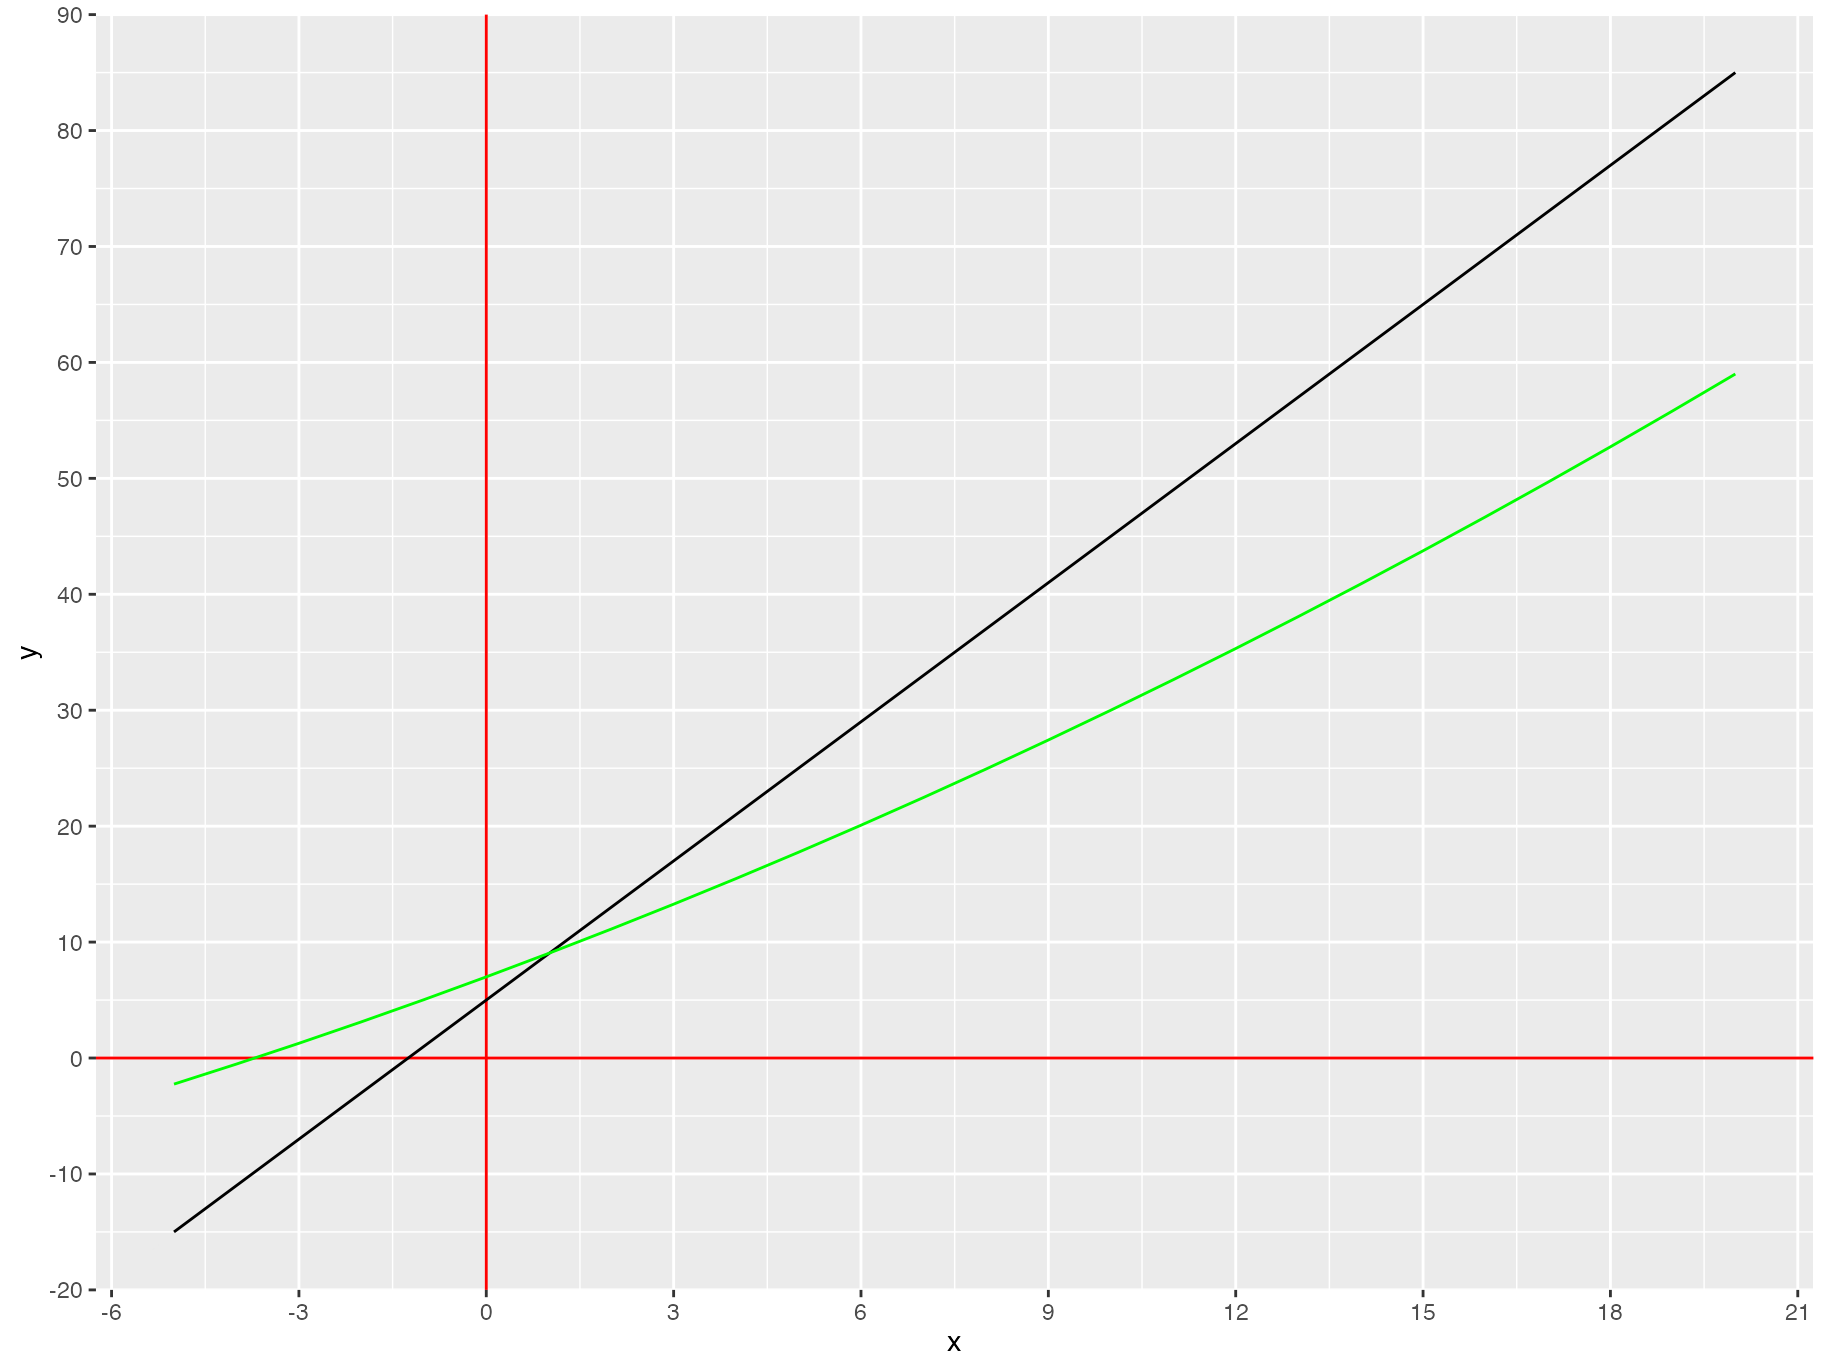

In [74]:
my_data |> mutate(y_curve = 0.03*x^2 + 2*x + 7) |> ggplot() + 
  aes(x=x, y=y) + 
  geom_hline(yintercept=0, color='red') + 
  geom_vline(xintercept=0, color="red") + 
  geom_line() + 
  geom_line(aes(x=x, y=y_curve), color='green') + 
  scale_y_continuous(n.breaks=10) + 
  scale_x_continuous(n.breaks=10) 

In [70]:
(60-30)/(12-4.5)

[1] 4

In [20]:
?geom_hline

In [ ]:
#L=linear, I=indepence, N=normality, E=equal variance

In [ ]:
#Simple linear regression
y = b0 + b1x 

$$
y = \beta_0 + \beta_1x
$$

$$
y = \beta_0 + \beta_1x + \beta_2w
$$

$$
y = \beta_0 + \beta_1x + \beta_2w + \beta_3{z_1} + \beta_4{z_2}
$$

$$
y = \beta_0 + \beta_1x + \beta_2w + \beta_3{z_1} + \beta_4{z_2} + \beta_5{a_1} + \beta_6{a_2} + \beta_7{a_3}
$$

- beta0 = 7k
- beta1 = 3k
- beta2 = 1k

- salary = 19
- salary = 20

- 2 - m vs f
- sex -> m, m, f, m
- male -> 1, 1, 0, 1
- #female - > 0, 0, 1, 0 (reference)

- highest_edu

- edu = pri, pri, sec, pri, tet, pri, sec

- pri = 1, 1, 0, 0, 0, 1, 0
- sec = 0, 0, 1, 0, 0, 0, 1
- tet = 0, 0, 0, 0, 1, 0, 0

- #pri = 100 -> ref
- sec = 010
- tet = 001

- z1 = 4k
- z2 = 10k

- man, worked for 15years and has a Phd
- y = 7 + 10*3(years) + 1(sex) + 15*10(edu)




In [3]:
nhanes <- read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Lengt...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning messages:
1: Removed 26 rows containing non-finite outside the scale range
(`stat_smooth()`). 
2: Removed 26 rows containing missing values or values outside the scale range
(`geom_point()`). 


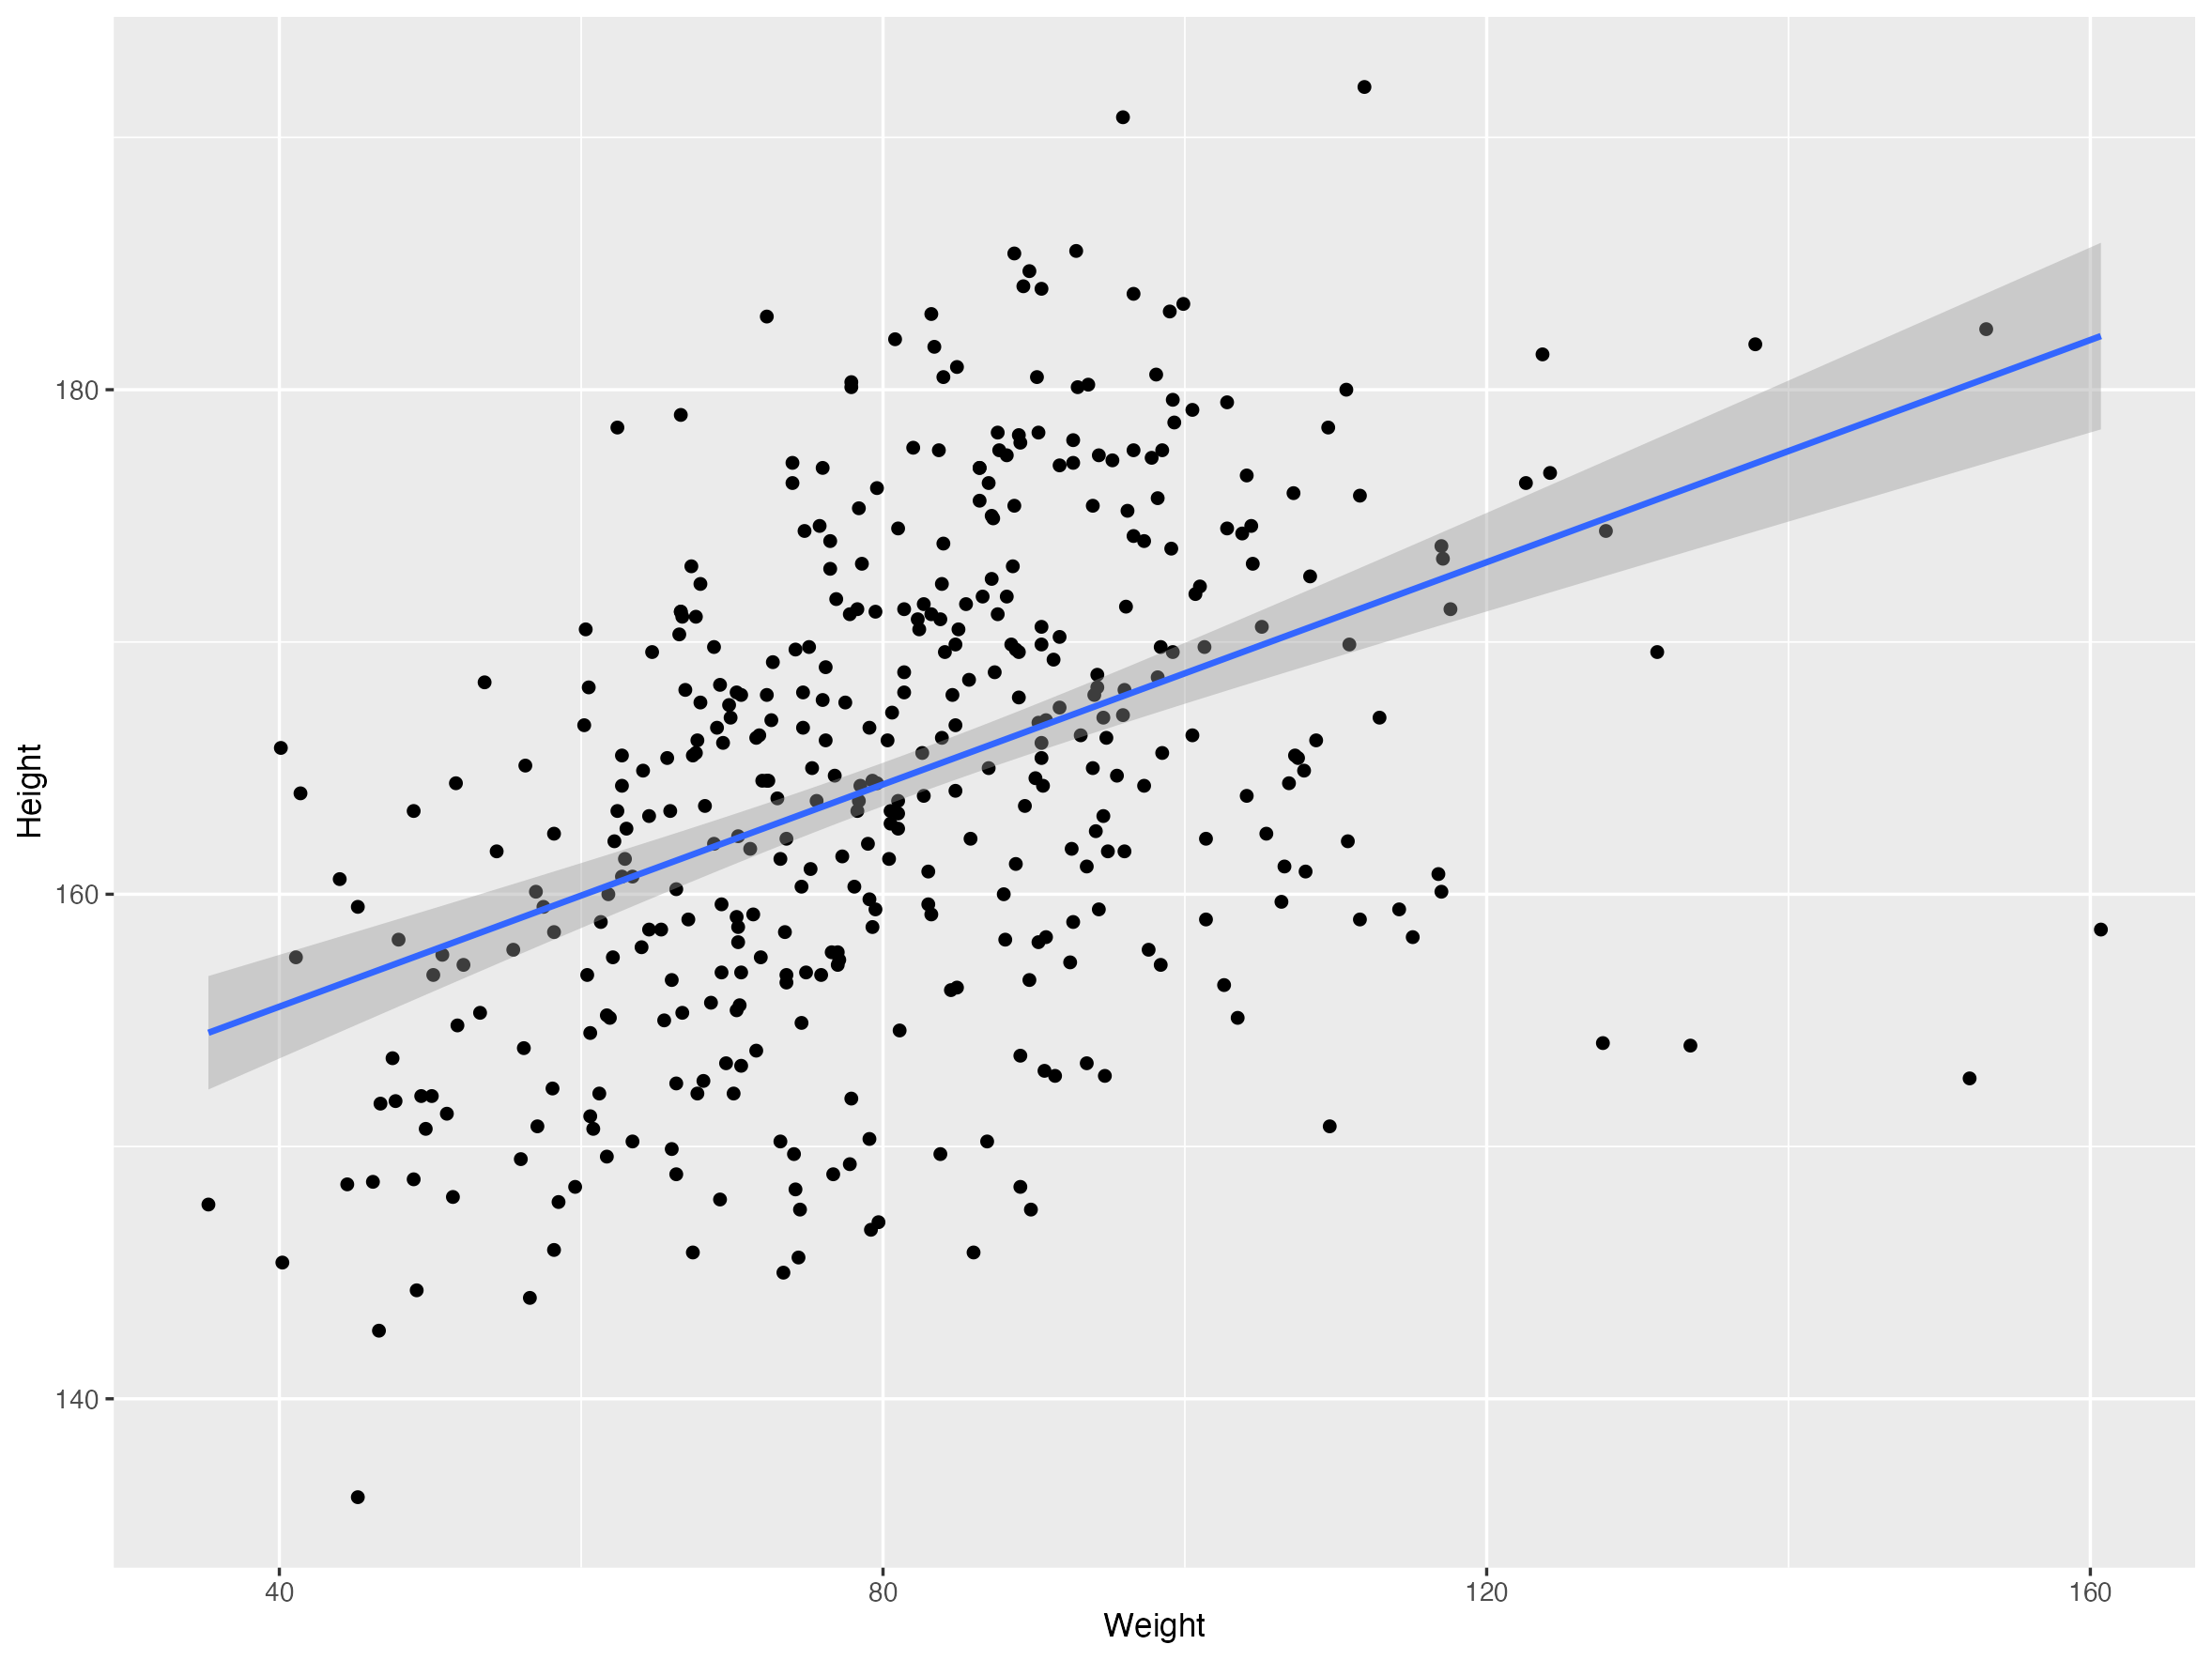

`geom_smooth()` using formula = 'y ~ x'

In [13]:
nhanes |> 
  filter(Age %in% 70:72) |> 
  select(Age, Gender, Race1, Weight, Height) -> nhanes.old 


nhanes.old|>
  ggplot() + aes(Weight, Height) + geom_point() + geom_smooth(method=lm)


In [17]:
lm(Height ~ Weight, nhanes.old) -> base.model

In [21]:
base.model |> tbl_regression()

<R HTML widget>

In [26]:
height_pred = base.model |> predict(nhanes.old)

In [28]:
nhanes.old |> mutate(Height_pred = height_pred) -> nhanes.old

Warning messages:
1: Removed 26 rows containing missing values or values outside the scale range
(`geom_point()`). 
2: Removed 25 rows containing missing values or values outside the scale range
(`geom_point()`). 


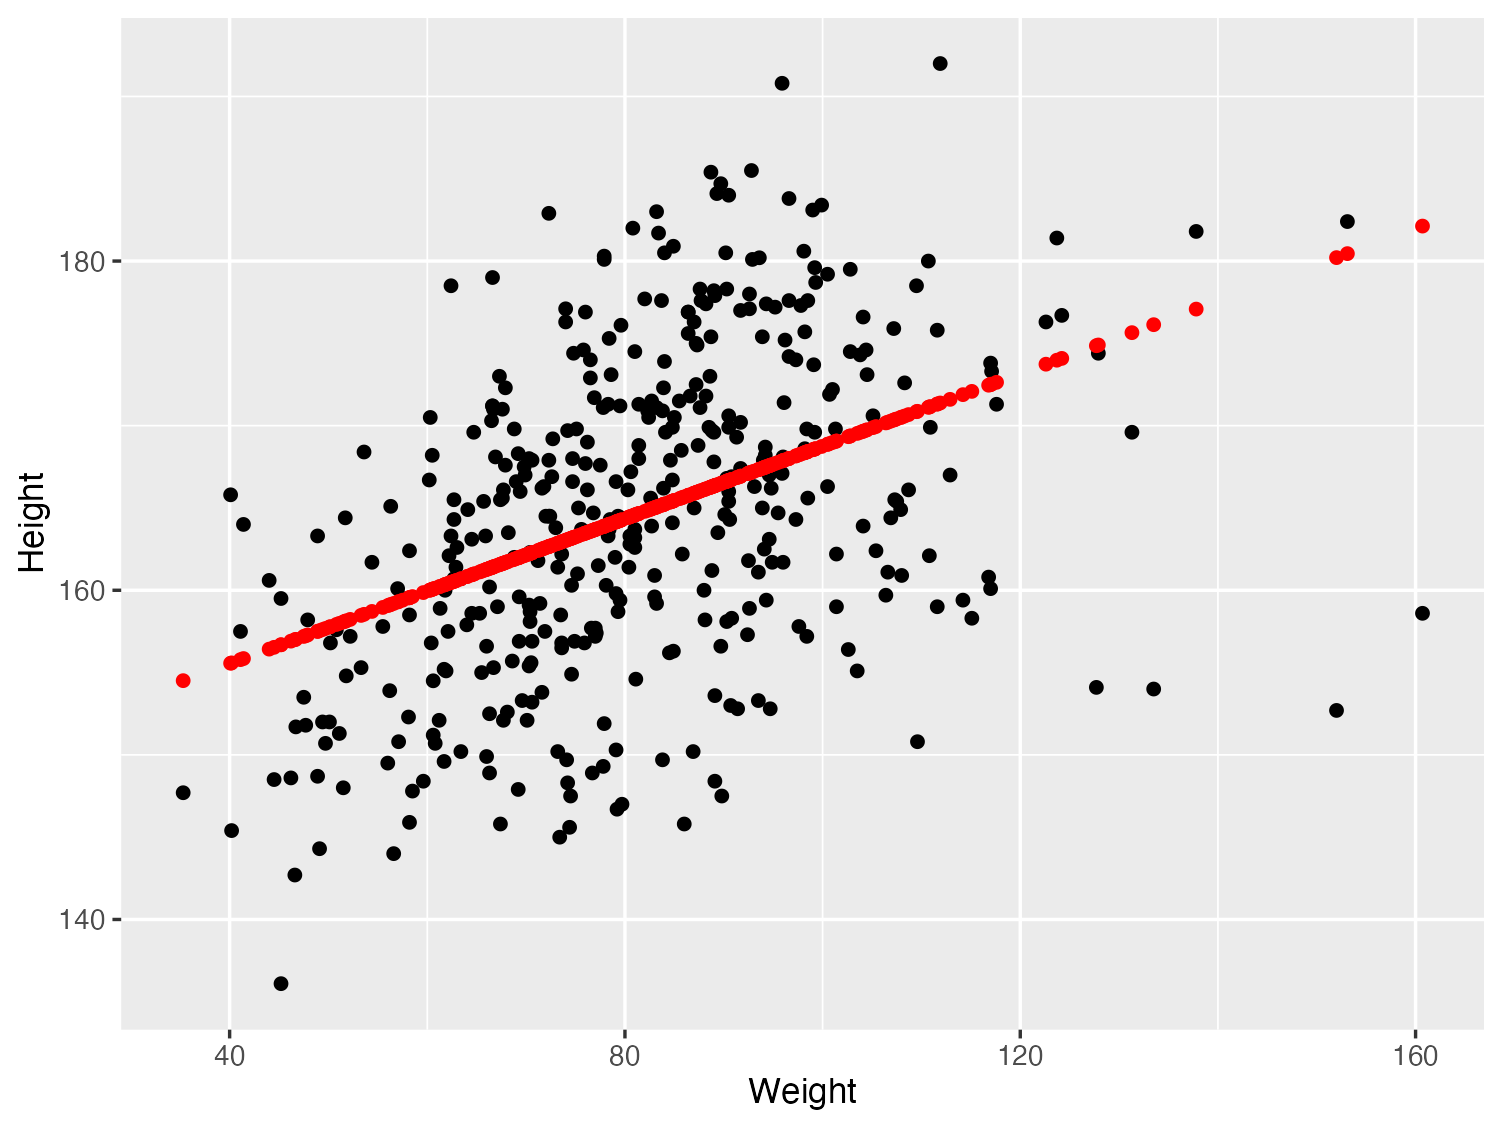

In [37]:
nhanes.old |> ggplot() + 
  aes(Weight, Height) + 
  geom_point() + 
  geom_point(aes(y=height_pred), color='red')

In [59]:
lm(Height ~ Weight + Gender + Race1, nhanes.old) -> gender.model

gender.model |> tbl_regression()

Characteristic,Beta,95% CI,p-value
Weight,0.11,"0.07, 0.14",<0.001
Gender,,,
female,—,—,
male,12,"10, 13",<0.001
Race1,,,
Black,—,—,
Hispanic,-5.1,"-7.6, -2.6",<0.001
Mexican,-6.2,"-8.8, -3.7",<0.001
Other,-4.0,"-6.6, -1.4",0.002
White,1.3,"-0.37, 3.0",0.13


In [60]:
gender.model |> predict(nhanes.old) -> Height_wg

In [61]:
nhanes.old |> mutate(Height_predG = Height_wg) -> nhanes.old

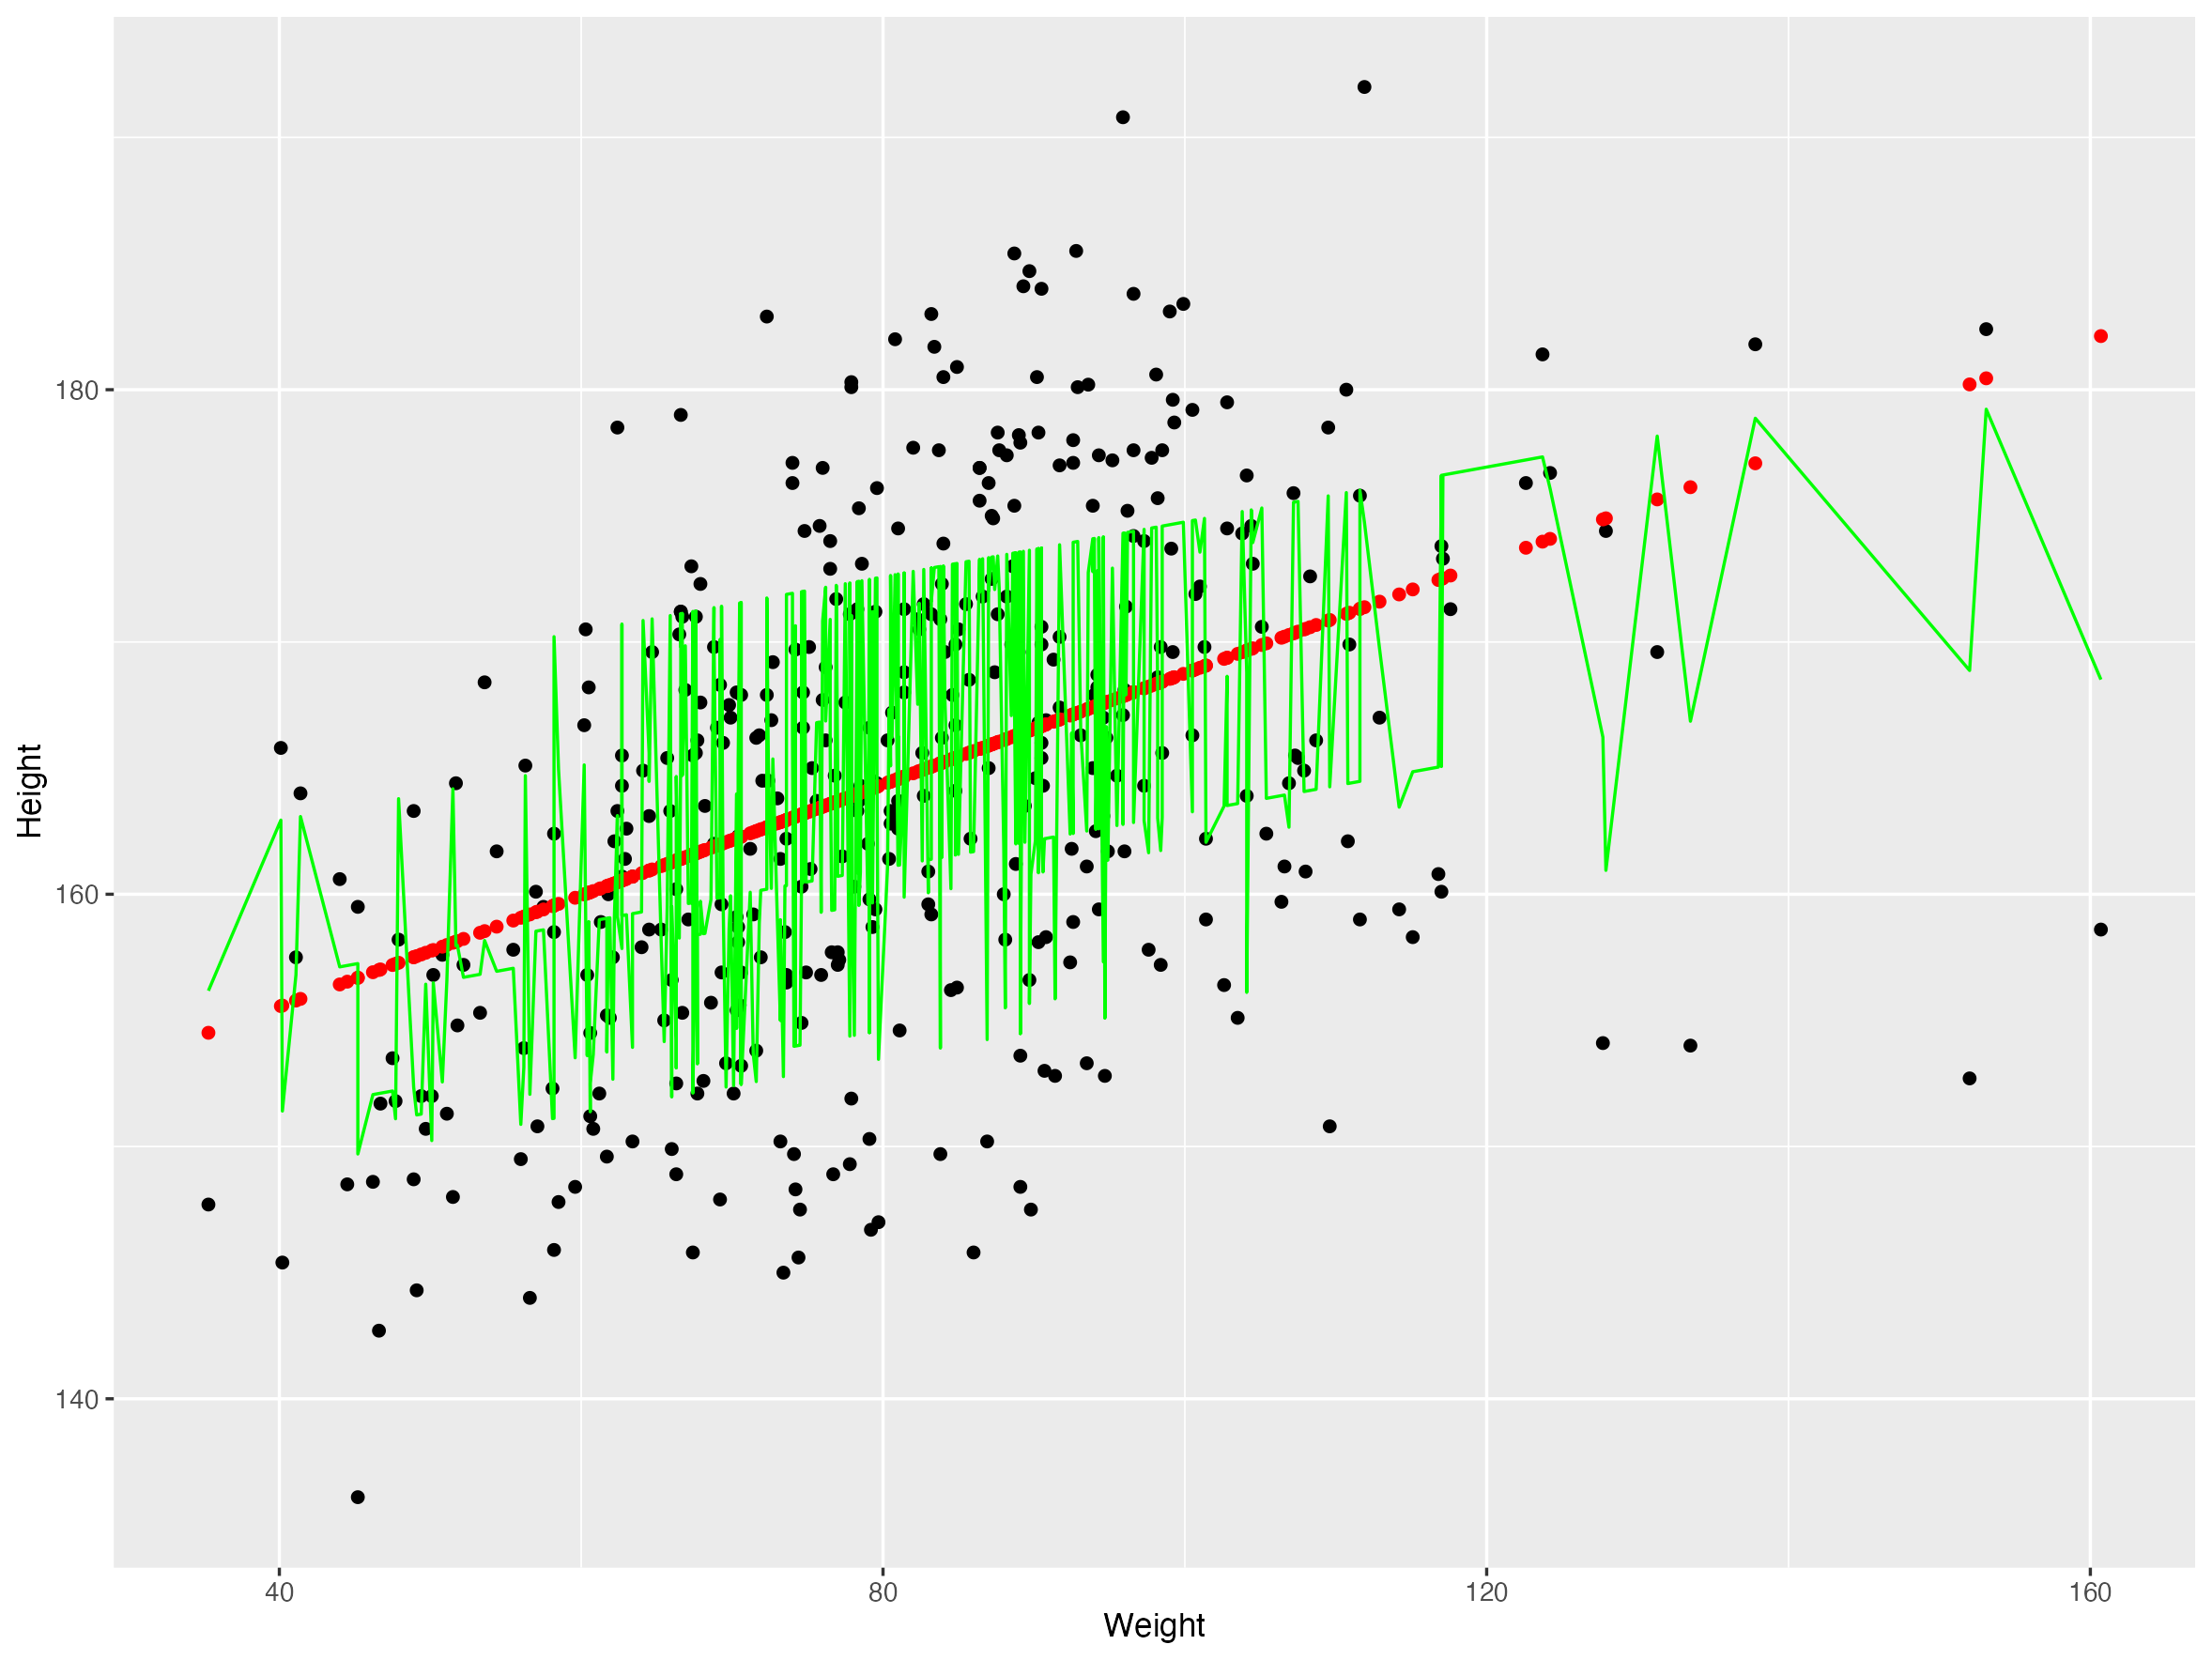

In [62]:
nhanes.old |> filter(complete.cases(nhanes.old)) |> ggplot() + aes(Weight, Height)  + 
  geom_point() + 
  geom_point(aes(y=Height_pred), color='red') + 
  geom_line(aes(x=Weight, y=Height_predG), color='green')

In [63]:
summary(base.model)


Call:
lm(formula = Height ~ Weight, data = nhanes.old)

Residuals:
     Min       1Q   Median       3Q      Max 
-27.5094  -6.0213   0.2776   6.0172  22.9456 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 146.73416    1.92111  76.380   <2e-16 ***
Weight        0.22023    0.02303   9.562   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.842 on 409 degrees of freedom
  (26 observations deleted due to missingness)
Multiple R-squared:  0.1827,	Adjusted R-squared:  0.1807 
F-statistic: 91.43 on 1 and 409 DF,  p-value: < 2.2e-16


In [64]:
summary(gender.model)


Call:
lm(formula = Height ~ Weight + Gender + Race1, data = nhanes.old)

Residuals:
     Min       1Q   Median       3Q      Max 
-17.1411  -4.2126   0.1415   4.3044  19.2913 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   151.02730    1.63348  92.457  < 2e-16 ***
Weight          0.10879    0.01814   5.998 4.45e-09 ***
Gendermale     11.54410    0.64943  17.776  < 2e-16 ***
Race1Hispanic  -5.11654    1.28391  -3.985 8.00e-05 ***
Race1Mexican   -6.24215    1.29704  -4.813 2.11e-06 ***
Race1Other     -3.99446    1.31287  -3.043   0.0025 ** 
Race1White      1.30675    0.85069   1.536   0.1253    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.366 on 404 degrees of freedom
  (26 observations deleted due to missingness)
Multiple R-squared:  0.5816,	Adjusted R-squared:  0.5754 
F-statistic:  93.6 on 6 and 404 DF,  p-value: < 2.2e-16


In [74]:
nhanes |> 
  filter(Age %in% 70:72) |> 
  select(Age, Gender, Race1, Weight, Height, Poverty) -> nhanes.old.og 

nhanes.old.og |> filter(complete.cases(nhanes.old.og)) -> nhanes.old.og

In [75]:
lm(Height ~ ., nhanes.old.og) |> step(direction = 'backward')

Start:  AIC=1340.52
Height ~ Age + Gender + Race1 + Weight + Poverty

          Df Sum of Sq   RSS    AIC
- Age      1      23.8 13999 1339.1
- Poverty  1      73.0 14048 1340.4
<none>                 13975 1340.5
- Weight   1     953.3 14928 1362.4
- Race1    4    1594.1 15569 1371.6
- Gender   1   11686.0 25661 1558.5

Step:  AIC=1339.13
Height ~ Gender + Race1 + Weight + Poverty

          Df Sum of Sq   RSS    AIC
- Poverty  1      73.7 14072 1339.0
<none>                 13999 1339.1
- Weight   1    1007.9 15006 1362.3
- Race1    4    1580.5 15579 1369.9
- Gender   1   11665.0 25664 1556.5

Step:  AIC=1339.03
Height ~ Gender + Race1 + Weight

         Df Sum of Sq   RSS    AIC
<none>                14072 1339.0
- Weight  1    1004.4 15077 1362.0
- Race1   4    2094.5 16167 1381.3
- Gender  1   11676.2 25748 1555.7



Call:
lm(formula = Height ~ Gender + Race1 + Weight, data = nhanes.old.og)

Coefficients:
  (Intercept)     Gendermale  Race1Hispanic   Race1Mexican     Race1Other  
    151.96853       11.74950       -3.99941       -5.94680       -4.58789  
   Race1White         Weight  
      1.15845        0.09661  


In [76]:
lm(formula = Height ~ Gender + Race1 + Weight, data = nhanes.old.og) -> best.model

In [77]:
best.model |> tbl_regression()

Characteristic,Beta,95% CI,p-value
Gender,,,
female,—,—,
male,12,"10, 13",<0.001
Race1,,,
Black,—,—,
Hispanic,-4.0,"-6.8, -1.2",0.005
Mexican,-5.9,"-8.7, -3.2",<0.001
Other,-4.6,"-7.4, -1.8",0.001
White,1.2,"-0.57, 2.9",0.2
Weight,0.10,"0.06, 0.13",<0.001
